# 5장 1강: 배깅과 랜덤포레스트

## 실습 목표
이번 실습에서는 **Ames Housing** 데이터를 이용하여 배깅과 랜덤포레스트의 핵심 원리를 확인합니다.

- 하나의 의사결정나무와 여러 나무를 모은 배깅의 차이를 확인합니다.
- 배깅에서 여러 회귀 모델의 예측을 평균내는 이유를 이해합니다.
- 랜덤포레스트의 부트스트랩과 피처 무작위 선택 개념을 확인합니다.
- OOB Score와 Feature Importance를 확인합니다.
- 여러 나무를 평균낼 때 분산이 줄어드는 이유를 설명합니다.

> 교안에 나온 범위만 사용합니다.

## 실습 환경 / 데이터
- Python, pandas, numpy, matplotlib, scikit-learn
- 데이터: `Ames_Housing.csv`
- 예측 대상: `SalePrice`

사용 특성:
`OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, `TotalBsmtSF`, `1stFlrSF`,
`2ndFlrSF`, `FullBath`, `TotRmsAbvGrd`, `YearBuilt`, `YearRemodAdd`, `Fireplaces`

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import r2_score

house = pd.read_csv("Ames_Housing.csv")

features = [
    "OverallQual","GrLivArea","GarageCars","GarageArea",
    "TotalBsmtSF","1stFlrSF","2ndFlrSF","FullBath",
    "TotRmsAbvGrd","YearBuilt","YearRemodAdd","Fireplaces"
]

X = house[features]
y = house["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
display(X.isna().sum().to_frame("missing"))

Train: (1168, 12)
Test: (292, 12)


,missing
OverallQual,0
GrLivArea,0
GarageCars,0
GarageArea,0
TotalBsmtSF,0
1stFlrSF,0
2ndFlrSF,0
FullBath,0
TotRmsAbvGrd,0
YearBuilt,0


# 필수 1. 하나의 나무와 Bagging 비교

## 문제 1. Decision Tree 하나를 학습하세요.
1. `DecisionTreeRegressor(random_state=42)` 사용
2. Train 학습
3. Train/Test 예측
4. Train R², Test R² 계산
5. 두 점수 차이 해석

In [3]:
# TODO
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_train_pred = dt.predict(X_train)
dt_test_pred = dt.predict(X_test)
dt_train_r2 = r2_score(y_train, dt_train_pred)
dt_test_r2 = r2_score(y_test, dt_test_pred)
print(f'Decision Tree Train R2: {dt_train_r2}')
print(f'Decision Tree Test R2: {dt_test_r2}')
print(f'차이: {dt_train_r2 - dt_test_r2}')

Decision Tree Train R2: 0.9999007920351307
Decision Tree Test R2: 0.7938734688847873
차이: 0.20602732315034344


### Q1. Train R²는 매우 높은데 Test R²가 더 낮다면 무엇을 의미하나요?

**답변:** 과적합이 일어났다는 뜻. 깊이 제한이 없는 의사결정나무는 리프 하나에 샘플이 거의 하나만 남을 때까지 분기한다. 그래서 학습 데이터는 거의 외워버리지만, 처음 보는 데이터에서는 성능이 크게 떨어진다. 단일 트리는 학습 데이터가 조금만 바뀌어도 구조가 크게 달라지는, 즉 분산이 큰 모델이라는 걸 보여준다.

## 문제 2. Bagging을 적용하세요.
1. 기본 모델은 `DecisionTreeRegressor(random_state=42)`
2. `BaggingRegressor`
3. `n_estimators=50`
4. `random_state=42`
5. Test R² 계산
6. `max_features="sqrt`
7. Decision Tree 하나와 비교

In [4]:
# TODO
bag = BaggingRegressor(estimator=DecisionTreeRegressor(max_features='sqrt', random_state=42), n_estimators=50, random_state=42)
bag.fit(X_train, y_train)

bag_test_r2 = r2_score(y_test, bag.predict(X_test))

result = pd.DataFrame({
    '모델': ['decision tree 1개', 'Bagging(50개)'],
    'test r2': [dt_test_r2, bag_test_r2]
})
display(result)

,모델,test r2
0,decision tree 1개,0.793873
1,Bagging(50개),0.891448


### Q2. 왜 각 나무를 서로 다른 부트스트랩 샘플로 학습하나요?

**답변:** 모든 나무를 같은 데이터로 학습하면 똑같은 나무가 50개 생기고, 평균을 내도 결과가 하나일 때와 같다. 부트스트랩으로 나무마다 조금씩 다른 데이터를 주면 나무들이 서로 다른 오차를 갖게 된다. 이런 오차들을 평균내면 서로 상쇄되어 분산이 줄어든다. 핵심은 다양한 모델을 만들어야 평균의 효과가 생긴다는 점이다.

# 필수 2. Random Forest의 OOB Score와 Feature Importance

## 문제 1. OOB Score를 확인하세요.
1. `RandomForestRegressor`
2. `n_estimators=100`
3. `bootstrap=True`
4. `oob_score=True`
5. `random_state=42`
6. Test R²와 `oob_score_` 출력

In [5]:
# TODO
rf = RandomForestRegressor(n_estimators=100, bootstrap=True, oob_score=True, random_state=42)
rf.fit(X_train, y_train)
rf_test_r2 = r2_score(y_test, rf.predict(X_test))
print(f'Random Forest Test r2: {rf_test_r2}')
print(f'OBB score: {rf.oob_score_}')


Random Forest Test r2: 0.8900753892164104
OBB score: 0.8190448550609115


### Q3. OOB 샘플은 무엇인가요?

**답변:** OOB 샘플은 부트스트랩 샘플링에서 뽑히지 않은 데이터이다. n개 중에서 n번 복원추출할 때 어떤 샘플이 한 번도 뽑히지 않을 확률은 36%정도이다. 그래서 각 나무마다 약 36%의 데이터가 학습에 쓰이지 않는다. 각 샘플을 그 샘플을 학습하지 않은 나무들로만 예측해서 점수를 내면, 별도의 검증 데이터 없이도 일반화 성능을 추정할 수 있다.

### Q4. OOB Score가 교차검증을 완전히 대체하나요?

**답변:** 완전히 대체하지는 못한다. OOB는 추가 학습 없이 빠르게 성능을 추정할 수 있다는 장점이 있지만, 한계들도 존재한다.

## 문제 2. Feature Importance를 확인하세요.
1. `feature_importances_` 사용
2. 특성명과 중요도 DataFrame 생성
3. 내림차순 정렬
4. 막대그래프
5. 가장 높은 중요도 특성 확인

,feature,importance
0,OverallQual,0.568166
1,GrLivArea,0.145061
4,TotalBsmtSF,0.059064
5,1stFlrSF,0.047472
6,2ndFlrSF,0.044405
3,GarageArea,0.033536
9,YearBuilt,0.031569
10,YearRemodAdd,0.022596
2,GarageCars,0.017413
8,TotRmsAbvGrd,0.012278


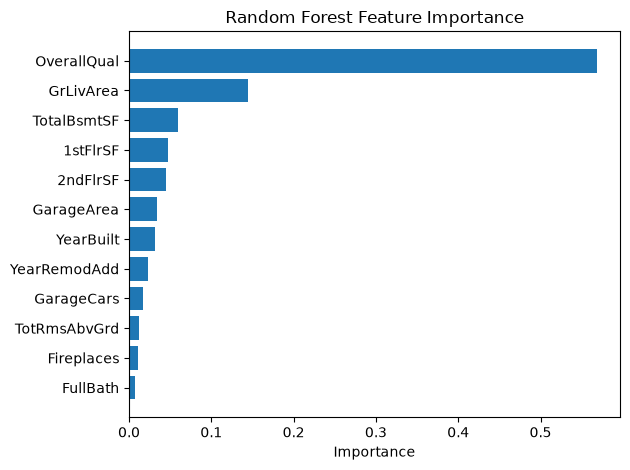

가장 중요한 특성: OverallQual


In [6]:
# TODO
result2 = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
display(result2)

plt.Figure(figsize=(6,4))
plt.barh(result2['feature'], result2['importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()
print(f'가장 중요한 특성: {result2.iloc[0]['feature']}')

### Q5. Feature Importance가 높다는 것이 그 변수가 주택가격의 원인이라는 뜻인가요?

**답변:** 아니다. Feature Importance는 그 변수가 모델에서 얼마나 중요한지만을 나타내는 값이다. 예측에 많이 쓰였다는 뜻이지, 원인이라는 뜻은 아니다. 이번 데이터에서도 GarageCars와 GarageArea, TotRmsAbvGrd와 GrLivArea처럼 비슷한 정보를 가진 변수가 있어서 중요도 해석에 주의가 필요하다.

# 과제 1. 나무 수와 예측 안정성 확인

`tree_counts = [1, 10, 50, 100]`을 사용하세요.

각 나무 수에서:
1. RandomForestRegressor 생성
2. `bootstrap=True`, `random_state=42`
3. Train 학습
4. Test R² 계산
5. DataFrame 정리
6. 나무 수에 따른 성능 변화 확인
7. 여러 예측의 평균과 분산 감소 관계 설명

In [7]:
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호(-)가 깨지는 것 방지

,n_estimator,r2
0,1,0.742870
1,10,0.883597
2,50,0.889467
3,100,0.890075


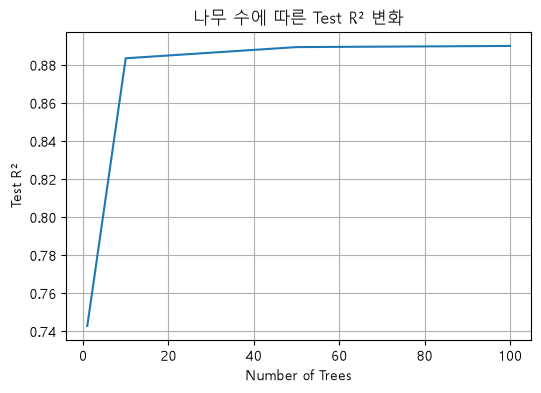

In [10]:
# TODO
tree_counts = [1, 10, 50, 100]
results = []

for i in tree_counts:
    model = RandomForestRegressor(
        n_estimators=i,
        bootstrap=True,
        random_state=42
    )
    model.fit(X_train, y_train)
    r2 = r2_score(y_test, model.predict(X_test))
    results.append({'n_estimator': i, 'r2': r2})

results_df = pd.DataFrame(results)
display(results_df)

plt.figure(figsize=(6, 4))
plt.plot(results_df["n_estimator"], results_df["r2"])
plt.xlabel("Number of Trees")
plt.ylabel("Test R²")
plt.title("나무 수에 따른 Test R² 변화")
plt.grid(True)
plt.show()

### Q6. 나무 수를 늘리면 왜 예측이 더 안정적으로 변하나요?

**답변:** 각 나무의 예측을 확률변수로 보고, 각각의 분산을 σ²라고 하면 나무들이 서로 독립이라면 B개의 평균의 분산은 σ²/B로 줄어든다. 나무가 많을수록 개별 나무의 우연한 오차가 서로 상쇄되기 때문에, 평균 예측이 데이터의 작은 변화에 덜 흔들리고 안정적이게 된다.

### Q7. 나무 수를 계속 늘리면 분산이 무한히 0으로 줄어드나요?

**답변:** 아니다. 실제로는 나무들이 같은 학습 데이터에서 나왔기 때문에 완전히 독립이 아니다. 서로 어느정도의 상관이 있기 때문에 무한히 0으로 줄어들지는 않는다.

# 실습 마무리
1. 부트스트랩 샘플링은 어떤 방식인가요?
2. Bagging 회귀에서는 여러 모델의 예측을 어떻게 합치나요?
3. Random Forest가 Bagging에 추가하는 무작위성은 무엇인가요?
4. OOB 샘플은 평균적으로 약 몇 %인가요?
5. Feature Importance가 높다는 것은 무엇을 의미하나요?
6. Bagging이 Decision Tree와 특히 잘 맞는 이유는 무엇인가요?

- 부트스트랩 샘플링은 원본 데이터에서 같은 크기만큼 복원추출하는 방식이에요. 같은 샘플이 여러 번 뽑힐 수도 있고, 한 번도 안 뽑힐 수도 있어요.
- Bagging 회귀에서는 각 모델의 예측값을 평균내요. 분류에서는 다수결 투표를 해요.
- Random Forest는 데이터 샘플링(부트스트랩)에 더해, 나무가 분기할 때마다 특성 일부만 무작위로 골라 그중에서 최적의 분기를 찾아요. 이렇게 하면 나무 간 상관이 줄어들어요.
- OOB 샘플은 평균적으로 약 **36.8%**예요. 이는 e⁻¹에서 나온 값이에요.
- Feature Importance가 높다는 것은 그 변수가 분기에서 오차를 많이 줄여 예측에 많이 기여했다는 뜻이에요. 인과관계를 의미하지는 않아요.
- Bagging이 Decision Tree와 잘 맞는 이유는 깊은 나무가 편향은 낮고 분산은 큰 모델이기 때문이에요. 배깅은 편향을 거의 그대로 유지하면서 분산만 줄여주므로, 이런 약점을 정확히 보완해요. 이번 실습에서도 Test R²가 0.79에서 0.89로 개선되는 것을 확인했어요.